In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             precision_recall_curve, confusion_matrix,
                             ConfusionMatrixDisplay)

In [3]:
# 1.Load the data
df=pd.read_csv("titanic3.csv")
df.head(3)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1st,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1st,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1st,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [4]:
df.shape

(1309, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   object 
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(3), object(8)
memory usage: 143.3+ KB


In [6]:
df.describe(include="O")

,pclass,name,sex,ticket,cabin,embarked,boat,home.dest
count,1309,1309,1309,1309,295,1307,486,745
unique,1,1307,2,929,186,3,27,369
top,1st,"Connolly, Miss. Kate",male,CA. 2343,C23 C25 C27,S,13,"New York, NY"
freq,1309,2,843,11,6,914,39,64


In [50]:
df_model = df.drop(columns=["name","ticket","cabin","boat","body","home.dest","pclass"])


In [51]:
df_model = df_model.dropna(subset=["survived"])


In [52]:
df.duplicated().sum()


np.int64(0)

In [53]:
df.isnull().sum()

pclass       0
survived     0
name         0
sex          0
age          0
sibsp        0
parch        0
ticket       0
fare         0
cabin        0
embarked     0
boat         0
body         0
home.dest    0
dtype: int64

In [54]:
(df.isnull().any(axis=1).sum()/df.shape[0])*100

np.float64(0.0)

In [55]:
def imputenull(data):
    for col in data.columns:
        if col in data.select_dtypes(include=['float64', 'int64']).columns:
                if data[col].isna().any() and data[col].skew()<3:
                    data[col] = data[col].fillna(data[col].mean())
                else:
                    data[col] = data[col].fillna(data[col].median())
        else:
            if data[col].isna().any():
                data[col] = data[col].fillna(data[col].mode()[0])
                #data[col] = data[col].fillna(data[col].value_counts().index[0])


imputenull(df)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   object 
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1309 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1309 non-null   float64
 9   cabin      1309 non-null   object 
 10  embarked   1309 non-null   object 
 11  boat       1309 non-null   object 
 12  body       1309 non-null   float64
 13  home.dest  1309 non-null   object 
dtypes: float64(3), int64(3), object(8)
memory usage: 143.3+ KB


In [57]:
df.describe()

,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,0.381971,29.881138,0.498854,0.385027,33.281086,160.809917
std,0.486055,12.883193,1.041658,0.865560,51.741500,29.591544
min,0.000000,0.170000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,22.000000,0.000000,0.000000,7.895800,160.809917
50%,0.000000,29.881138,0.000000,0.000000,14.454200,160.809917
75%,1.000000,35.000000,1.000000,0.000000,31.275000,160.809917
max,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [58]:
df.duplicated().sum()


np.int64(0)

In [78]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

outliers_summary = {}
for col in numeric_cols:
    outliers = detect_outliers(df, col)
    outliers_summary[col] = len(outliers)

print("Outliers in numeric columns:")
print(outliers_summary)

Outliers in numeric columns:
{'survived': 0, 'age': 101, 'sibsp': 57, 'parch': 307, 'fare': 171, 'body': 121}


<Axes: ylabel='survived'>

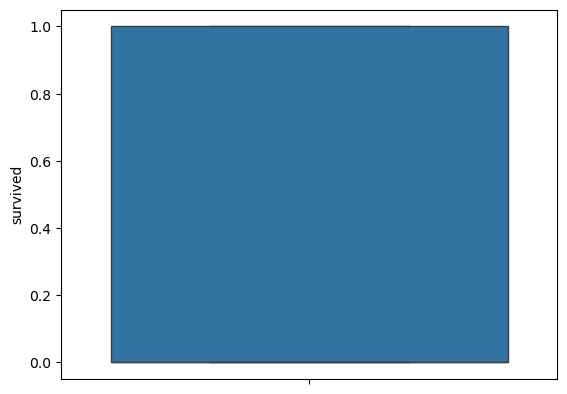

In [81]:
sns.boxplot(df.survived)


In [61]:
# Define X, y
y = df['survived']
X = df.drop(columns=['survived'])

In [68]:
X = pd.get_dummies(X, drop_first=True)


In [69]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve 

In [71]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [72]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

In [73]:
# Baseline logistic regression model
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)

# Make predictions
y_pred = logreg.predict(X_test)
y_pred

array([0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1])

In [74]:
y_pred_proba = logreg.predict_proba(X_test)[:,1]
y_pred_proba

array([0.01908863, 0.82617205, 0.02275106, 0.04330727, 0.04312284,
       0.82328956, 0.02684166, 0.93443212, 0.04059337, 0.99576782,
       0.00143339, 0.01251776, 0.98662086, 0.02275106, 0.02046381,
       0.98480758, 0.02240004, 0.19760096, 0.98885662, 0.02528558,
       0.2212241 , 0.03771335, 0.03423461, 0.9677574 , 0.86817905,
       0.2621952 , 0.03161802, 0.9652966 , 0.99655364, 0.16134552,
       0.88752002, 0.95134623, 0.98575681, 0.98809199, 0.03366712,
       0.02432463, 0.99380272, 0.03187419, 0.98435747, 0.04514076,
       0.99224883, 0.91850323, 0.12491132, 0.01449564, 0.03463464,
       0.02273586, 0.01771467, 0.99353837, 0.9956021 , 0.22051349,
       0.99207877, 0.02275784, 0.90014727, 0.96577134, 0.0599557 ,
       0.03301667, 0.00695003, 0.98064479, 0.02265948, 0.9910445 ,
       0.02914561, 0.96591142, 0.99420767, 0.91886528, 0.99307986,
       0.98150199, 0.98556263, 0.01116987, 0.06028382, 0.06825987,
       0.06116409, 0.06142352, 0.06002938, 0.9435467 , 0.95715

In [75]:
# Model evaluation metrics
def evaluate_model(y_true, y_pred, y_pred_proba, set_name="Test"):
    accuracy = np.mean(y_true == y_pred)
    precision = np.sum((y_pred == 1) & (y_true == 1)) / np.sum(y_pred == 1)
    recall = np.sum((y_pred == 1) & (y_true == 1)) / np.sum(y_true == 1)
    f1 = 2 * (precision * recall) / (precision + recall)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    metrics = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }
    
    print(f"\n{set_name} Set Performance:")
    print("-" * 30)
    for metric, value in metrics.items():
        print(f"{metric:12}: {value:.4f}")
    
    return metrics

In [76]:
test_metrics = evaluate_model(y_test, y_pred, y_pred_proba, "Test")


Test Set Performance:
------------------------------
Accuracy    : 0.9580
Precision   : 1.0000
Recall      : 0.9068
F1-Score    : 0.9511
ROC-AUC     : 0.9933


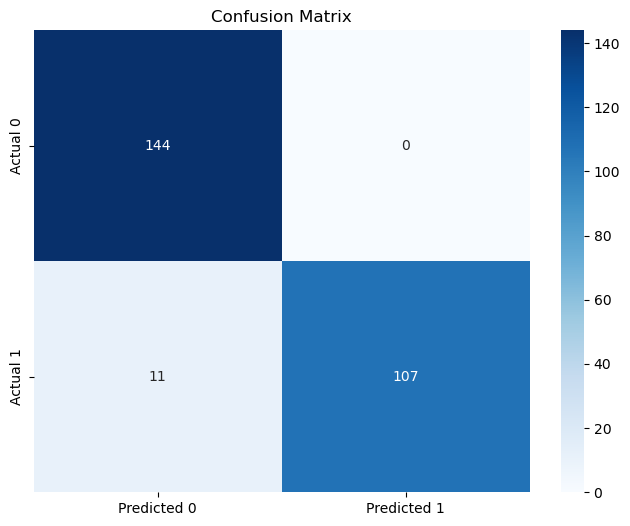

In [77]:
# 10.3 Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.show()

## Insights

- Female passengers had higher survival rates.
- Passenger class influenced survival probability.
- Younger passengers had slightly better survival chances.

## Conclusion

A Logistic Regression model was built to predict passenger survival using the Titanic dataset.
The model demonstrates how machine learning can be used for predictive analysis.